# Notebook 08 — Random Forest e XGBoost
O notebook usa RF como modelo principal. XGBoost é opcional caso o pacote esteja instalado.


In [2]:
# Random Forest para previsão do teor de argila
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

DATA_DIR = Path(r"C:\Users\PC\Desktop\RESET")
CANDIDATE_FILES = [
    "raw_nir_data_Saturin.csv",
    "raw_mir_data_Saturin.csv",
    "raw_nir_data_saturin.csv",
    "raw_mir_data_saturin.csv",
]


def resolve_dataset():
    for file_name in CANDIDATE_FILES:
        file_path = DATA_DIR / file_name
        if file_path.exists():
            return file_path
    raise FileNotFoundError(f"Arquivo espectral não encontrado em {DATA_DIR}")


def read_csv_robust(file_path):
    for encoding in ("utf-8", "cp1252", "latin1"):
        try:
            return pd.read_csv(file_path, encoding=encoding, low_memory=False)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"Não foi possível decodificar {file_path.name}")


dataset_path = resolve_dataset()
df = read_csv_robust(dataset_path)
df = df.drop(columns=[column for column in df.columns if str(column).lower().startswith("unnamed")], errors="ignore")

spectral_columns = [column for column in df.columns if str(column).lower().startswith("wl_")]
if not spectral_columns:
    for column in df.columns:
        try:
            wavelength = float(str(column).strip().replace(",", "."))
        except (TypeError, ValueError):
            continue
        if 300 <= wavelength <= 4000:
            spectral_columns.append(column)

if not spectral_columns:
    raise ValueError("Nenhuma coluna espectral foi encontrada no arquivo carregado.")

clay_aliases = {"clay", "clay_gkg", "argila", "argila_gkg"}
clay_column = next(
    (column for column in df.columns if str(column).strip().lower() in clay_aliases),
    None,
)
if clay_column is None:
    raise ValueError("Coluna de argila não encontrada no dataset.")

X = df[spectral_columns].apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(df[clay_column], errors="coerce")
valid_rows = X.notna().any(axis=1) & y.notna()
X = X.loc[valid_rows].copy()
y = y.loc[valid_rows].copy()
X = X.fillna(X.median()).fillna(0.0)

# Remove bandas constantes para evitar atributos sem informação.
variable_columns = X.std(axis=0, skipna=True) > 1e-12
X = X.loc[:, variable_columns]

Xtr, Xte, ytr, yte = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
)

rf = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
)
rf.fit(Xtr, ytr)
p = rf.predict(Xte)

rf_metrics = {
    "R2": r2_score(yte, p),
    "RMSE": np.sqrt(mean_squared_error(yte, p)),
    "MAE": mean_absolute_error(yte, p),
}

print(f"Dataset: {dataset_path.name}")
print(f"Amostras válidas: {len(y)}")
print(f"Bandas variáveis: {X.shape[1]}")
print(f"Alvo: {clay_column}")
print(
    f"RF | R2={rf_metrics['R2']:.4f} | "
    f"RMSE={rf_metrics['RMSE']:.4f} | MAE={rf_metrics['MAE']:.4f}"
)


Dataset: raw_nir_data_Saturin.csv
Amostras válidas: 29249
Bandas variáveis: 2151
Alvo: Clay_gkg
RF | R2=0.6033 | RMSE=102.5932 | MAE=73.5894


In [4]:
try:
    from xgboost import XGBRegressor
    xgb=XGBRegressor(n_estimators=300,max_depth=5,learning_rate=.05,subsample=.8,colsample_bytree=.8,random_state=42,n_jobs=2)
    xgb.fit(Xtr,ytr)
    px=xgb.predict(Xte)
    print('XGBoost | R2=',r2_score(yte,px),'RMSE=',mean_squared_error(yte,px)**.5)
except ImportError:
    print('XGBoost não instalado. Instale com: pip install xgboost')


XGBoost | R2= 0.5723494593810606 RMSE= 106.5199220689063


INTERPRETAÇÃO XGBOOST
Comparação dos modelos no mesmo conjunto de teste:


,modelo,R2,RMSE,MAE
0,Random Forest,0.6033,102.5932,73.5894
1,XGBoost,0.5723,106.5199,78.7008


Melhor modelo pelo RMSE: Random Forest
A importância do XGBoost mede quanto cada banda contribui para as divisões das árvores. Valores maiores indicam maior utilidade preditiva para o modelo, mas não representam causalidade química.

20 bandas mais importantes para o XGBoost:


,band,wavelength,importance
0,395,395.00,0.010177
1,1180,1180.00,0.009150
2,392,392.00,0.008428
3,605,605.00,0.008153
4,612,612.00,0.008130
5,381,381.00,0.007979
6,2439,2439.00,0.007407
7,1151,1151.00,0.007358
8,2453,2453.00,0.006592
9,1243,1243.00,0.006579


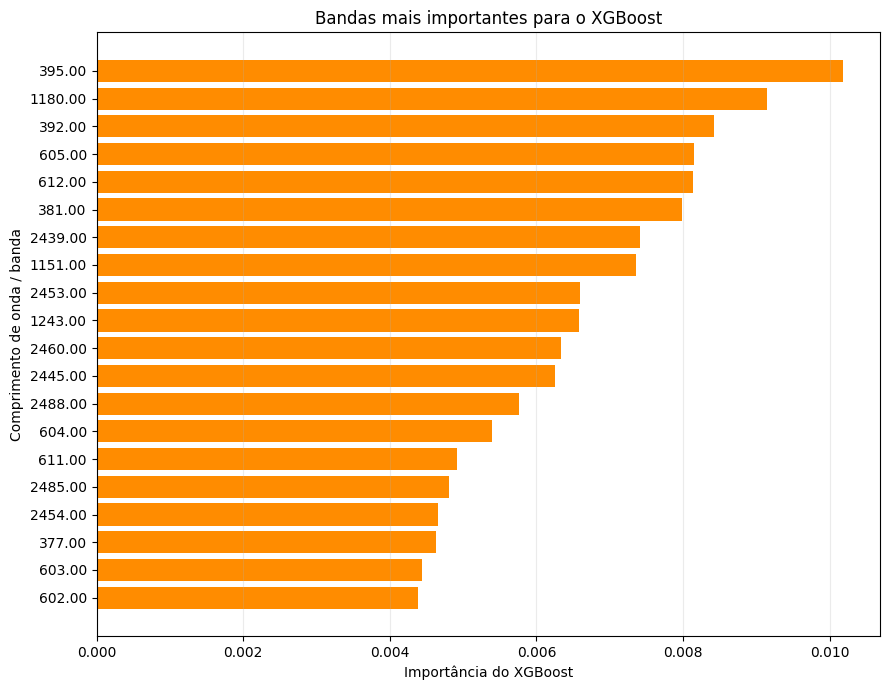

Interpretação: o Random Forest explica mais variabilidade do teor de argila que o XGBoost neste conjunto de teste.
Conclusão: use o modelo com menor RMSE e maior R2 para a previsão final. As bandas importantes devem ser confirmadas com validação cruzada e conhecimento agronômico.


In [6]:
# Interpretação do modelo XGBoost
import matplotlib.pyplot as plt

if "xgb" not in globals() or "px" not in globals():
    print("XGBoost não está disponível. Execute a célula XGBoost acima primeiro.")
else:
    xgb_metrics = {
        "R2": r2_score(yte, px),
        "RMSE": np.sqrt(mean_squared_error(yte, px)),
        "MAE": mean_absolute_error(yte, px),
    }

    comparison = pd.DataFrame([
        {
            "modelo": "Random Forest",
            "R2": rf_metrics["R2"],
            "RMSE": rf_metrics["RMSE"],
            "MAE": rf_metrics["MAE"],
        },
        {
            "modelo": "XGBoost",
            "R2": xgb_metrics["R2"],
            "RMSE": xgb_metrics["RMSE"],
            "MAE": xgb_metrics["MAE"],
        },
    ]).sort_values("RMSE").reset_index(drop=True)

    importance = pd.DataFrame({
        "band": X.columns,
        "importance": xgb.feature_importances_,
    }).sort_values("importance", ascending=False).reset_index(drop=True)

    def band_label(column):
        text = str(column).replace("wl_", "").replace(",", ".")
        try:
            return f"{float(text):.2f}"
        except ValueError:
            return str(column)

    importance["wavelength"] = importance["band"].map(band_label)
    top_importance = importance.head(20)
    best_model = comparison.loc[0, "modelo"]

    print("INTERPRETAÇÃO XGBOOST")
    print("=" * 35)
    print("Comparação dos modelos no mesmo conjunto de teste:")
    display(comparison.round(4))
    print(f"Melhor modelo pelo RMSE: {best_model}")
    print(
        "A importância do XGBoost mede quanto cada banda contribui para as divisões "
        "das árvores. Valores maiores indicam maior utilidade preditiva para o modelo, "
        "mas não representam causalidade química."
    )
    print("\n20 bandas mais importantes para o XGBoost:")
    display(top_importance[["band", "wavelength", "importance"]].round(6))

    plt.figure(figsize=(9, 7))
    plot_importance = top_importance.sort_values("importance")
    plt.barh(plot_importance["wavelength"], plot_importance["importance"], color="darkorange")
    plt.xlabel("Importância do XGBoost")
    plt.ylabel("Comprimento de onda / banda")
    plt.title("Bandas mais importantes para o XGBoost")
    plt.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()

    if xgb_metrics["R2"] > rf_metrics["R2"]:
        print(
            "Interpretação: o XGBoost explica mais variabilidade do teor de argila "
            "que o Random Forest neste conjunto de teste."
        )
    elif xgb_metrics["R2"] < rf_metrics["R2"]:
        print(
            "Interpretação: o Random Forest explica mais variabilidade do teor de argila "
            "que o XGBoost neste conjunto de teste."
        )
    else:
        print("Interpretação: os dois modelos apresentaram desempenho equivalente no teste.")

    print(
        "Conclusão: use o modelo com menor RMSE e maior R2 para a previsão final. "
        "As bandas importantes devem ser confirmadas com validação cruzada e conhecimento agronômico."
    )




### Interpretação do XGBoost

O XGBoost utilizou principalmente as seguintes bandas espectrais:

- **395 nm**: banda mais importante.
- **1180 nm**: segunda maior contribuição.
- **392 nm e 381 nm**: região próxima do visível.
- **605–612 nm**: conjunto de bandas importantes.
- **1151 e 1243 nm**: regiões relevantes no NIR.
- **2439–2488 nm**: várias bandas importantes no MIR.

Comparação dos modelos:

```text
Random Forest
R²:   0.6033
RMSE: 102.5932
MAE:  73.5894

XGBoost
R²:   0.5723
RMSE: 106.5199
MAE:  78.7008
```

Neste conjunto de teste, o **Random Forest apresentou melhor desempenho** que o XGBoost, com maior $R^2$ e menores RMSE e MAE.

A importância apresentada pelo XGBoost indica quais bandas foram mais usadas nas divisões das árvores. Diferentemente do SHAP, ela não mostra se uma banda aumenta ou reduz a previsão, apenas sua relevância relativa para o modelo.

